# Viability landscape for VEGF and GLUT1 expression

This notebook visualizes the sign and magnitude of the fitness-generating function $G(u, y)$ across a range of VEGF expression ($u$) and GLUT1 expression ($y$).

The main goal is to identify the **viable region** where $G(u, y) > 0$ and the **viability boundary** defined by $G(u, y)=0$.

The lower bound of this range defines the critical threshold, whereas the upper bound corresponds to unsustainable conditions. To identify the viability condition, we substitute \( N = 1 \) into the G-function, yielding:


$$
G(u, y) = b\left[(1-e^{-ky})R(1-e^{-au}) - cu - hy - f\right].
$$

Here:
- $u$ is VEGF expression,
- $y$ is GLUT1 expression,
- $R$ is the background resource level,
- $a$ and $k$ control the efficacy of VEGF and GLUT1,
- $c$ and $h$ are the costs of VEGF and GLUT1 expression,
- $f$ is the baseline fitness cost,
- $b$ is a scaling factor.


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def G(u, y, R=100.0, a=0.05, k=0.05, c=0.01, h=0.01, f=0.005, b=0.5):
    """Fitness-generating function for joint VEGF (u) and GLUT1 (y) expression."""
    return b * ((1 - np.exp(-k * y)) * R * (1 - np.exp(-a * u)) - c * u - h * y - f)


## Parameter grid

We evaluate the function on a dense grid of VEGF and GLUT1 values.
Because the biologically relevant GLUT1 range spans multiple orders of magnitude, the vertical axis is displayed on a logarithmic scale.


In [3]:
u_vals = np.linspace(0, 20, 600)
y_pos = np.geomspace(1e-4, 1e4, 1600)
y_vals = np.concatenate(([0.0], y_pos))

U, Y = np.meshgrid(u_vals, y_vals)
Z = G(U, Y)


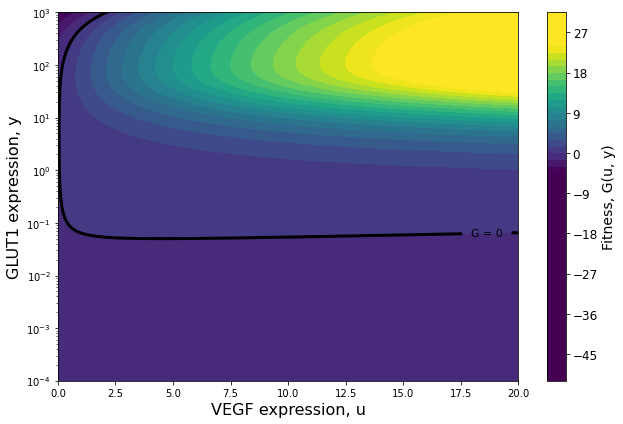

In [4]:
plt.figure(figsize=(9, 6))

# Clip the color scale so the structure near G = 0 is easier to see.
vmin = np.percentile(Z, 5)
vmax = np.percentile(Z, 95)

cf = plt.contourf(
    U,
    Y,
    Z,
    levels=60,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

cbar = plt.colorbar(cf)
cbar.set_label("Fitness, G(u, y)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

cs = plt.contour(
    U,
    Y,
    Z,
    levels=[0],
    colors="black",
    linewidths=3,
)
plt.clabel(cs, fmt={0: "G = 0"}, fontsize=11)

plt.xlabel("VEGF expression, u", fontsize=16)
plt.ylabel("GLUT1 expression, y", fontsize=16)
plt.yscale("log")
plt.ylim(1e-4, 1e3)
plt.tight_layout()
plt.show()


## Interpretation

- The filled contour shows the magnitude of fitness across the $(u, y)$ plane.
- The black contour marks the **viability boundary** $G(u, y)=0$.
- Points above this boundary correspond to parameter combinations with positive fitness, while points below it correspond to negative fitness.

This plot is useful for understanding which combinations of VEGF and GLUT1 investment can sustain growth under the chosen parameter values.
